In [ ]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt

# --- Database connection details ---
DB_HOST = None  # <YOUR DB HOST>
DB_USER = None  # <YOUR DB USER>
DB_PASSWORD = None  # <YOUR DB PASSWORD>
DB_NAME = None  # <YOUR DB NAME>

In [2]:
# --- Connect to the database ---
db_connection = mysql.connector.connect(
    host=DB_HOST,
    user=DB_USER,
    password=DB_PASSWORD,
    database=DB_NAME,
    charset="utf8mb4",
    collation="utf8mb4_unicode_ci",
)

# Create a cursor object
cursor = db_connection.cursor()

In [10]:
# get tweet ids
query = "SELECT id FROM tweets"
cursor.execute(query)
results = cursor.fetchall()
tweet_ids = [result[0] for result in results]
print(f"Retrieved {len(tweet_ids)} tweet ids.")

Retrieved 11934 tweet ids.


In [11]:
# get notes
placeholders = ", ".join(["%s"] * len(tweet_ids))
query = f"""SELECT 
    noteId,
    tweetId,
    classification,
    believable,
    harmful,
    misleadingOther,
    misleadingFactualError,
    misleadingManipulatedMedia,
    misleadingOutdatedInformation,
    misleadingMissingImportantContext,
    misleadingUnverifiedClaimAsFact,
    misleadingSatire,
    notMisleadingOther,
    notMisleadingFactuallyCorrect,
    notMisleadingOutdatedButNotWhenWritten,
    notMisleadingClearlySatire,
    notMisleadingPersonalOpinion
FROM notes WHERE tweetId IN ({placeholders})"""
cursor.execute(query, tweet_ids)
results = cursor.fetchall()
full_notes = pd.DataFrame(
    results,
    columns=[
        "noteId",
        "tweetId",
        "classification",
        "believable",
        "harmful",
        "misleadingOther",
        "misleadingFactualError",
        "misleadingManipulatedMedia",
        "misleadingOutdatedInformation",
        "misleadingMissingImportantContext",
        "misleadingUnverifiedClaimAsFact",
        "misleadingSatire",
        "notMisleadingOther",
        "notMisleadingFactuallyCorrect",
        "notMisleadingOutdatedButNotWhenWritten",
        "notMisleadingClearlySatire",
        "notMisleadingPersonalOpinion",
    ],
)
note_ids = [str(id) for id in list(full_notes["noteId"].unique())]
print(f"Retrieved {len(full_notes)} notes.")

Retrieved 61723 notes.


In [12]:
# get ratings for the notes
placeholders = ", ".join(["%s"] * len(note_ids))
query = f"""SELECT 
    noteId,
    raterParticipantId,
    helpfulnessLevel,
    ratedOnTweetId
FROM note_ratings WHERE noteId IN ({placeholders})"""
cursor.execute(query, note_ids)
results = cursor.fetchall()
full_ratings = pd.DataFrame(
    results,
    columns=["noteId", "raterParticipantId", "helpfulnessLevel", "ratedOnTweetId"],
)
print(f"Retrieved {len(full_ratings)} ratings.")

Retrieved 29631500 ratings.


In [13]:
# get full tweets
query = """
SELECT 
    id,
    text,
    created_at,
    author_id,
    retweet_count,
    reply_count,
    like_count,
    quote_count,
    bookmark_count,
    impression_count,
    interaction_score,
    action_count
FROM tweets
"""
cursor.execute(query)
results = cursor.fetchall()
full_tweets = pd.DataFrame(
    results,
    columns=[
        "id",
        "text",
        "created_at",
        "author_id",
        "retweet_count",
        "reply_count",
        "like_count",
        "quote_count",
        "bookmark_count",
        "impression_count",
        "interaction_score",
        "action_count",
    ],
)
print(f"Retrieved {len(full_tweets)} tweets.")

Retrieved 11934 tweets.


In [14]:
# calculate interaction scores and externalities


# get ratings score for the notes
ratings_map = {"HELPFUL": 1, "SOMEWHAT_HELPFUL": 0.5, "NOT_HELPFUL": 0}

notes_map = {
    "MISINFORMED_OR_POTENTIALLY_MISLEADING": -1,
    "NOT_MISLEADING": 1,
}

full_ratings["rating_score"] = full_ratings["helpfulnessLevel"].map(ratings_map)
full_notes["note_score"] = full_notes["classification"].map(notes_map)

# drop rows with NA values in note_score or rating_score
full_notes = full_notes.dropna(subset=["note_score"])
full_ratings = full_ratings.dropna(subset=["rating_score"])

# calculate the sum of the ratings for each note
note_ratings = (
    full_ratings[["noteId", "rating_score"]].groupby("noteId").sum().reset_index()
)
# add one because original noter agrees with the note
note_ratings["rating_score"] += 1

# add note_ratings to full_notes
full_notes = full_notes.merge(note_ratings, on="noteId", how="left")

# calculate the overall note score as the note score times the rating score
full_notes["note_rating"] = full_notes["note_score"] * full_notes["rating_score"]

In [ ]:
# add externality scores to tweets as the sum of the externality scores of the notes for each tweet
agg_note_rating_by_tweet = (
    full_notes[["tweetId", "note_rating"]].groupby("tweetId").sum().reset_index()
)
full_tweets = full_tweets.merge(
    agg_note_rating_by_tweet, left_on="id", right_on="tweetId", how="left"
)
full_tweets = full_tweets.rename(columns={"note_rating": "agg_post_rating"})

# drop rows with NA values in externality_score
full_tweets = full_tweets.dropna(subset=["agg_post_rating"])

# filter out tweets with no impressions
full_tweets = full_tweets[full_tweets["impression_count"] > 0]

full_tweets["agg_post_rating_per_impression"] = (
    full_tweets["agg_post_rating"] / full_tweets["impression_count"]
)
full_tweets["agg_post_rating_per_action"] = (
    full_tweets["agg_post_rating"] / full_tweets["action_count"]
)

avg_agg_post_rating_per_impression = full_tweets[
    "agg_post_rating_per_impression"
].mean()
avg_agg_post_rating_per_action = full_tweets["agg_post_rating_per_action"].mean()

In [16]:
print(full_tweets[["agg_post_rating", "action_count"]].describe())

       agg_post_rating  action_count
count     11855.000000  1.185500e+04
mean       -892.289793  7.379478e+04
std        1530.904285  1.593443e+05
min      -22308.500000  5.000000e+00
25%       -1210.500000  5.880000e+03
50%        -746.000000  2.032700e+04
75%        -474.500000  7.148200e+04
max       32199.500000  5.446737e+06


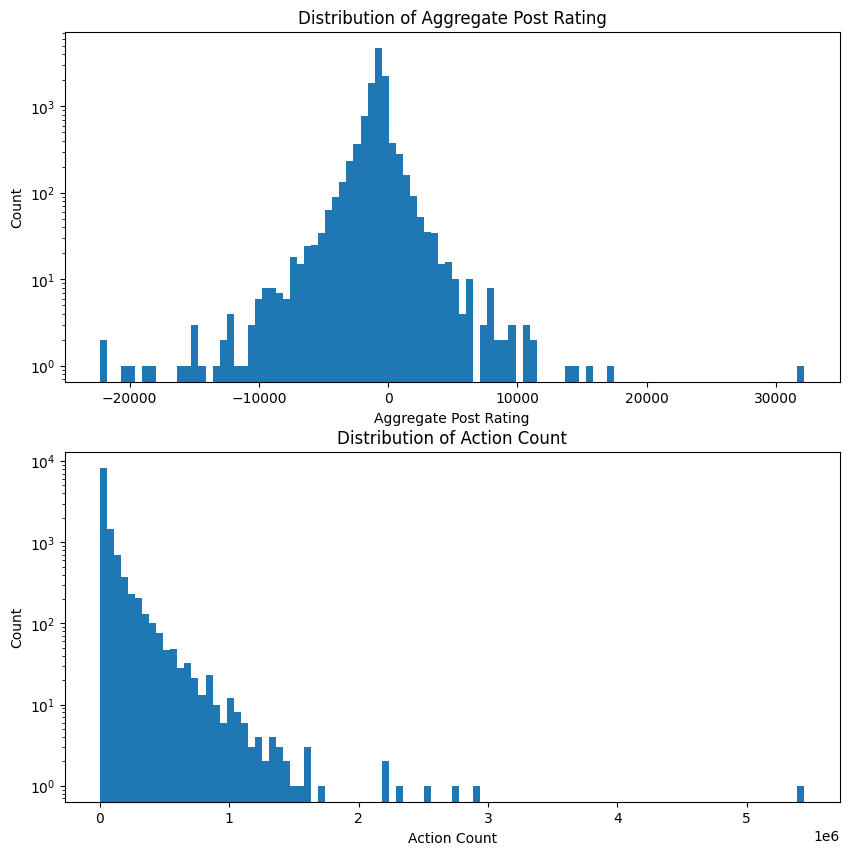

In [25]:
def plot_histograms(df):
    # plot histograms of externality cpm and action counts per 1000 impressions
    fig, ax = plt.subplots(2, 1, figsize=(10, 10))
    ax[0].hist(df["agg_post_rating"], bins=100, log=True)
    ax[0].set_xlabel("Aggregate Post Rating")
    ax[0].set_ylabel("Count")
    ax[0].set_title("Distribution of Aggregate Post Rating")
    ax[1].hist(df["action_count"], bins=100, log=True)
    ax[1].set_xlabel("Action Count")
    ax[1].set_ylabel("Count")
    ax[1].set_title("Distribution of Action Count")
    plt.show()


plot_histograms(full_tweets)

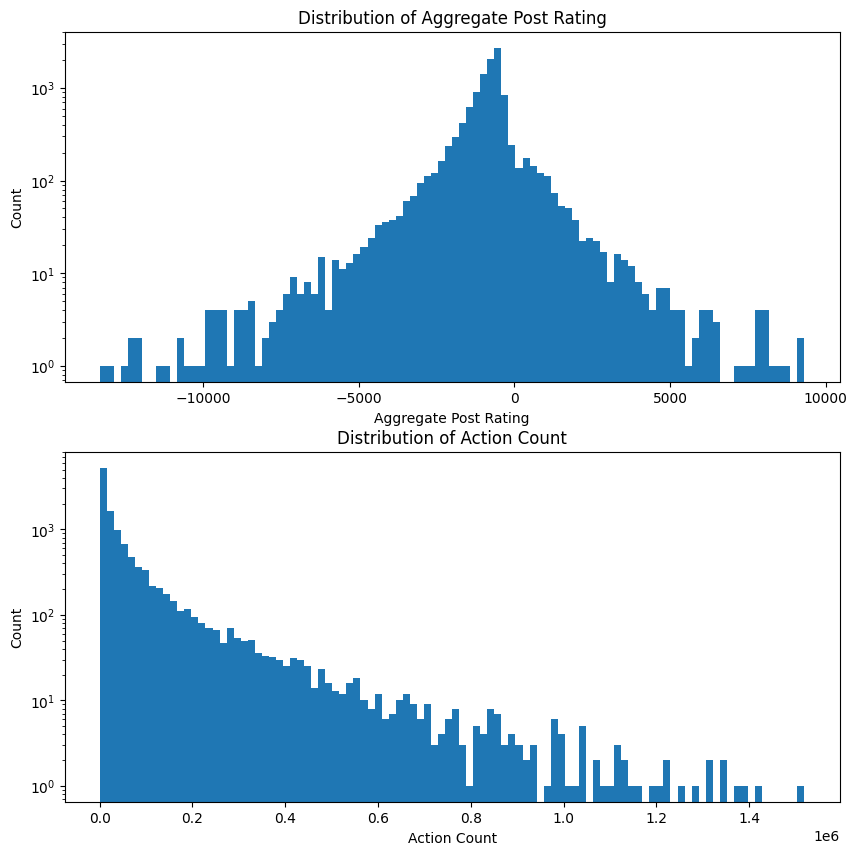

       agg_post_rating  action_count
count     11855.000000  1.185500e+04
mean       -892.289793  7.379478e+04
std        1530.904285  1.593443e+05
min      -22308.500000  5.000000e+00
25%       -1210.500000  5.880000e+03
50%        -746.000000  2.032700e+04
75%        -474.500000  7.148200e+04
max       32199.500000  5.446737e+06


In [35]:
# Remove outliers from agg_post_rating and action_count using top and bottom 0.1% as thresholds
bottom = full_tweets["agg_post_rating"].quantile(0.001)
top = full_tweets["agg_post_rating"].quantile(0.999)
full_tweets_no_outliers = full_tweets[
    (full_tweets["agg_post_rating"] >= bottom) & (full_tweets["agg_post_rating"] <= top)
]

bottom = full_tweets["action_count"].quantile(0.001)
top = full_tweets["action_count"].quantile(0.999)
full_tweets_no_outliers = full_tweets_no_outliers[
    (full_tweets_no_outliers["action_count"] >= bottom)
    & (full_tweets_no_outliers["action_count"] <= top)
]

plot_histograms(full_tweets_no_outliers)
print(full_tweets[["agg_post_rating", "action_count"]].describe())

df = full_tweets_no_outliers

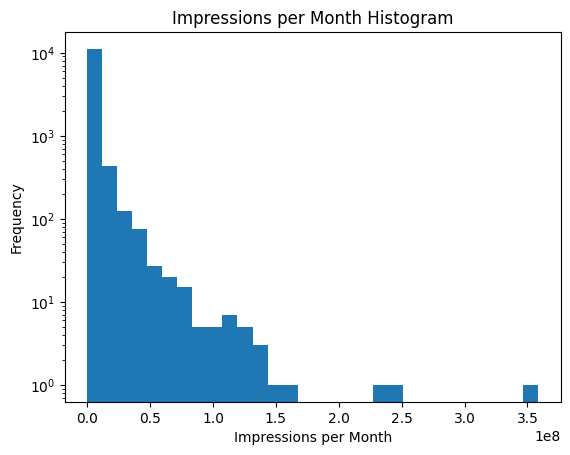

In [36]:
df["created_at_dt"] = pd.to_datetime(df["created_at"])
date_pulled = pd.to_datetime("02/02/2025")
df["days_old"] = (date_pulled - df["created_at_dt"]).dt.days
df["months_old"] = df["days_old"] / 30

# plot histogram of impressions per month
plt.hist(df["impression_count"] / (df["days_old"] / 30), bins=30, log=True)
plt.xlabel("Impressions per Month")
plt.ylabel("Frequency")
plt.title("Impressions per Month Histogram")

df["impressions_per_month"] = df["impression_count"] / df["months_old"]

In [37]:
# calculate the externality per month
df["agg_rating_per_month"] = df["agg_post_rating"] / df["months_old"]

# producer actions per month
df["actions_per_month"] = df["action_count"] / df["months_old"]

print(df[["agg_rating_per_month", "actions_per_month"]].describe())
df["v_score"] = df["actions_per_month"]
df["e_score"] = df["agg_rating_per_month"]

       agg_rating_per_month  actions_per_month
count          11811.000000       1.181100e+04
mean            -199.697349       1.976408e+04
std              646.873419       6.165509e+04
min           -21341.000000       8.732143e+00
25%             -222.421245       6.624722e+02
50%              -93.700441       2.823269e+03
75%              -42.564254       1.319641e+04
max            10745.000000       1.611199e+06


In [39]:
# --- Clean up ---
df.to_csv("full_tweets.csv", index=False)
cursor.close()
db_connection.close()

In [ ]:
# 1 / avg_agg_post_rating_per_action
print(f"avg actions per post rating: {1.0 / avg_agg_post_rating_per_action}")

# 1 / avg_agg_post_rating_per_impression
print(f"avg impressions per post rating: {1.0 / avg_agg_post_rating_per_impression}")

print(
    "\nGoldstein value: (1.53 $/kilo impressions / 1000) * avg impressions per post rating: "
)
print(f"{(1.53 / 1000) * (1.0 / avg_agg_post_rating_per_impression)}")

print("\nAcquisti value: 0.54 $/action * avg actions per post rating: ")
print(f"{0.54 * (1.0 / avg_agg_post_rating_per_action)}")

avg actions per post rating: -4.7026671512579625
avg impressions per post rating: -1771.9249935114142

Goldstein value: (1.53 $/kilo impressions / 1000) * avg impressions per post rating: 
-2.711045240072464

Acquisti value: 0.54 $/action * avg actions per post rating: 
-2.5394402616793
